# The dynamics of 4U 1820-30

In [1]:
import rebound
import reboundx
from kozai.delaunay import TripleDelaunay
import kozai.kl_period as klp
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

#constants -- we're using the same values as in the kozai code
yr2s = 3.15569e7
Ggrav = 6.67384e-8
Msun = 1.989e33
Rsun = 6.955e10
clight = 2.99792458e10
au = 1.49597870700e13

## Introduction

In [2]:
from IPython.display import Image
Image(url='https://heasarc.gsfc.nasa.gov/images/objects/binaries/4u1820s30_artists.jpg')

[4U 1820-30](https://heasarc.gsfc.nasa.gov/docs/objects/binaries/4u1820s30_artists.html?QuickLinksMenu=/hera/) is an interesting ultracompact low mass X-ray binary containing a neutron star that is accreting mass from a helium white dwarf in a $\approx 11\ \mathrm{min}$ orbit. The X-ray luminosity shows long term variations with a period of $\approx 170$ days that have been interpreted as being due to the effect of a third companion star. The idea is that the companion star causes Kozai oscillations of the eccentricity of the inner binary, modulating the accretion rate ([Chou & Grindlay 2001](https://ui.adsabs.harvard.edu/abs/2001ApJ...563..934C/abstract)). The companion has not been seen directly, but Chou & Grindlay used the magnitude of the optical counterpart to 4U 1820-30 to put a limit on its mass of $\approx 0.5 M_\odot$.

[Zdziarski et al. 2007](https://ui.adsabs.harvard.edu/abs/2007MNRAS.377.1006Z/abstract) modelled the dynamics of such a triple system, including how the mass transfer rate in the binary would be modulated as the eccentricity of the binary changed over time. They found solutions with modulation timescales of $\approx 170$ days, but noted a puzzling coincidence, that the GR precession period of the inner binary was approximately equal to the Kozai period. [Prodan & Murray (2012)](https://ui.adsabs.harvard.edu/abs/2012ApJ...747....4P/abstract) added precession due to the tidal buldge of the white dwarf, which they showed was about 4 times larger than the GR precession. They proposed that a natural solution to the coincidence pointed out by Zdziarski et al. is that the system is near a fixed point of the Kozai resonance (where the Kozai precession and GR/tidal precession terms do indeed cancel). The observed modulations then correspond to librations around this fixed point. They showed that expansion of the inner binary due to mass transfer naturally leads to trapping in this resonance. Both of these papers used the secular evolution equations for the Kozai interaction, considering both quadrupole and octupole terms.

A further puzzle about this system is that the orbital period is actually observed to be decreasing with time rather than increasing, as expected from mass transfer from a low mass donor. This remains unexplained, but is likely at least partially due to acceleration in the globular cluster potential ([Chou & Grindlay 2001](https://ui.adsabs.harvard.edu/abs/2001ApJ...563..934C/abstract)). Another question is the stability over time of the $\approx 170$ day oscillation. Earlier papers did not find any changes over time, consistent with the idea of a triple system. However, a recent paper by [Chou et al. 2025](https://ui.adsabs.harvard.edu/abs/2025ApJ...981...43C/abstract) shows that the period evolved over 36 years from 171 to 167 days, raising the question of whether this could be explained by the dynamics of a triple system.

In this notebook, we investigate the dynamics of the system with direct numerical integrations with REBOUND. We compare the results with integrations of the secular evolution equations using a version of the python package [`kozai`](https://github.com/joe-antognini/kozai/tree/master) modified to include tidal precession and orbital evolution due to mass transfer.

## Kozai cycles

First, check that we can reproduce Kozai oscillations in a triple system with REBOUND. We can compare with the [`kozai`](https://github.com/joe-antognini/kozai/tree/master) package that integrates the secular evolution equations for the orbital elements. One important thing is that we need to make sure we're working in the same reference frame as the secular calculation if we want to compare $\omega_p$ between the two calculations. To do this, we move into the [invariable plane](https://rebound.hanno-rein.de/ipython_examples/Rotations/) by rotating the REBOUND simulation so that the $z$-axis points in the same direction as the total angular momentum. The triple system we're using here is the default in `kozai`, consisting of three solar mass stars with inner binary $(a,e)=(1,0.1)$ and outer binary $(a,e)=(20,0.3)$.

In [3]:
# Set up a triple system which matches the default in the kozai code
# distances are in AU, masses in solar masses
m1,m2,m3 = (1, 1, 1)
ecc1, ecc2 = (0.1, 0.3)
inc2 = np.deg2rad(80)
omega0 = 0
a_outer = 20.0
P1 = 1 / np.sqrt(2) # period of the inner orbit in years

# REBOUND integration of the orbits
sim = rebound.Simulation()
sim.add(m=m1)
sim.add(m=m2, a=1, e=ecc1, omega=omega0, Omega=0)
sim.add(m=m3, a=a_outer, e=ecc2, inc=inc2, omega=0)
sim.move_to_com()

# rotate to the invariable plane so that we can compare with the secular calculation
rot = rebound.Rotation.to_new_axes(newz=sim.angular_momentum())
sim.rotate(rot)

Norbits = 1e5
Noutputs = 100000
Porb1 = sim.orbits()[0].P
Porb2 = sim.orbits()[1].P
times = np.linspace(0, Norbits*Porb1, Noutputs)
# initialize empty arrays for output
a1, a2, e1, e2, i1, i2, omega1, Omega1, Omega2 = [np.zeros(Noutputs) for _ in range(9)]

for i, t in enumerate(times):
    sim.integrate(t, exact_finish_time=1)
    o1 = sim.orbits()[0]
    o2 = sim.orbits()[1]    
    a1[i], a2[i] = o1.a, o2.a
    e1[i], e2[i] = o1.e, o2.e
    i1[i], i2[i] = o1.inc, o2.inc
    Omega1[i], Omega2[i] = o1.Omega, o2.Omega
    omega1[i] = o1.omega

# calculate the mutual inclination
cos_imut = (np.cos(i1)*np.cos(i2) + np.sin(i1)*np.sin(i2)*np.cos(Omega1 - Omega2))
imut = np.arccos(cos_imut)

# convert the times to years
times = times * (P1/Porb1)

In [4]:
# Integrate the secular equations using the kozai code
triple = TripleDelaunay(a1=1, a2=a_outer, e1=ecc1, e2=ecc2, inc=np.rad2deg(inc2), 
                        m1=m1, m2=m2, m3=m3, g1=np.rad2deg(omega0)+180)
triple.outfreq=1
triple.gr=False
triple.octupole=True
res = triple.evolve(times[-1])
eK = res[:,2]
tK = res[:,0]

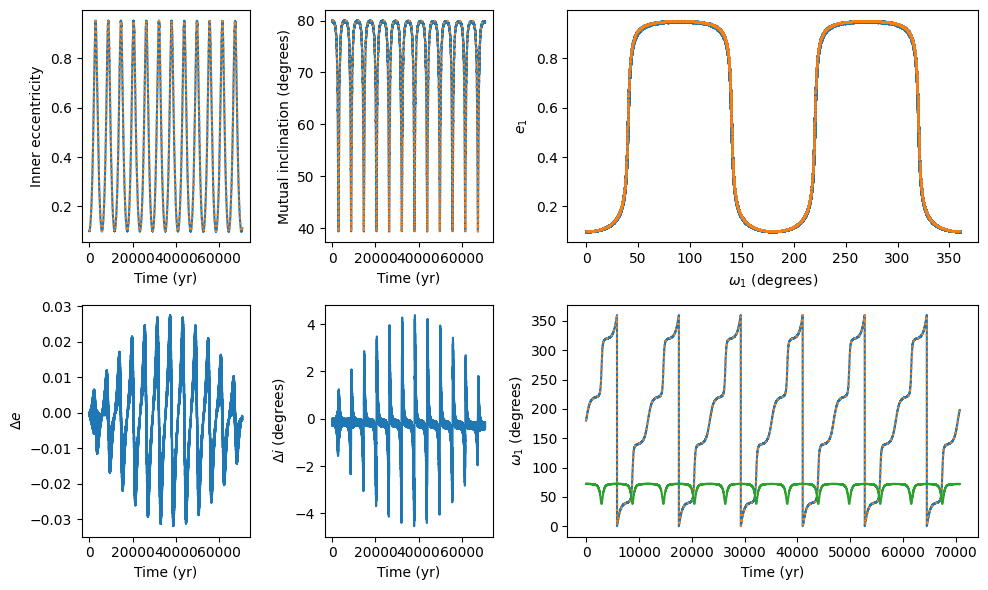

In [5]:
# Plot the results
fig = plt.figure(figsize = (10,6))
gs = fig.add_gridspec(2, 4)

# Top plot spans both columns
fig.add_subplot(gs[0, 0])
plt.plot(times, e1)
plt.plot(tK,eK,':')
#for tp in peak_times:
#    plt.plot((tp,tp),(0,1),"b:", alpha=0.2)
# check whether (1-e^2)cos^2(i) is conserved
#plt.plot(times, (1-e1*e1)*np.cos(imut)**2)
# prediction for maximum e
#emax = np.sqrt(1 - (5/3)*np.cos(inc2)**2)
#plt.plot((times[0],times[-1]), (emax,emax), "--")
plt.ylabel('Inner eccentricity')
plt.xlabel('Time (yr)')

w, h = plt.rcParams['figure.figsize']
fig.add_subplot(gs[1, 0])
plt.plot(times,e1 - np.interp(times,tK,eK))
plt.xlabel('Time (yr)')
plt.ylabel(r'$\Delta e$')

fig.add_subplot(gs[0, 1])
plt.plot(times, np.rad2deg(imut))
plt.plot(res[:,0],res[:,-1],':')
plt.ylabel('Mutual inclination (degrees)')
plt.xlabel('Time (yr)')

fig.add_subplot(gs[1,2:4])
plt.plot(times, ((omega1) * 180/np.pi) % 360)
plt.plot(tK,res[:,3],':')
plt.plot(times, np.rad2deg(i1))
plt.ylabel(r'$\omega_1$ (degrees)')
plt.xlabel('Time (yr)')

fig.add_subplot(gs[1, 1])
plt.plot(times, np.rad2deg(imut) - np.interp(times,res[:,0],res[:,-1]))
plt.xlabel('Time (yr)')
plt.ylabel(r'$\Delta i$ (degrees)')

fig.add_subplot(gs[0, 2:4])
plt.scatter(((omega1) * 180/np.pi) % 360, e1, s=0.5)
plt.scatter(res[:,3], res[:,2], s=0.5)
#plt.xlim((0,360))
plt.ylabel(r'$e_1$')
plt.xlabel(r'$\omega_1$ (degrees)')

plt.tight_layout()
plt.show()

Time resolution = 0.71 yr
Kozai period is 5858.16 +- 26.38 yr (estimate was 3771.24 yr)


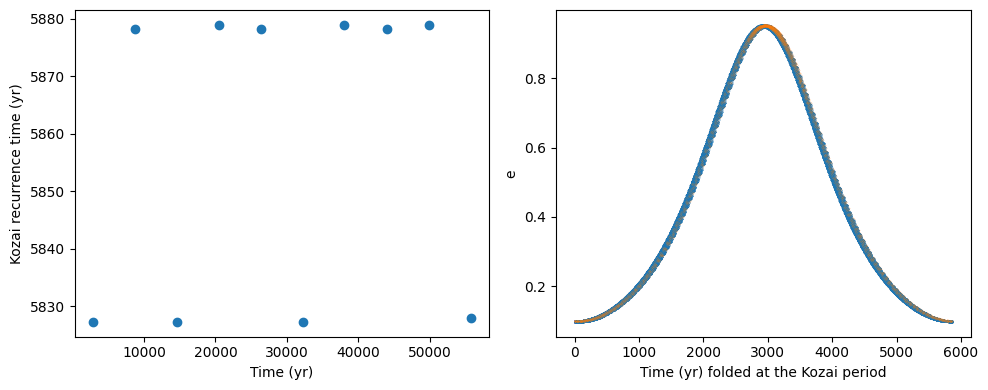

In [6]:
# estimate of the period of Kozai oscillations
PKa = (Porb2**2/Porb1) * (P1/Porb1)

# get the period from the e(t) curve
# Find peaks - we provide an estimate of the peak spacing in index
ind, properties = find_peaks(e1, distance = len(e1) * PKa/(times[-1]-times[0]))
peak_times = times[ind]
#print("Peak times:", peak_times)
#print("Periods:", peak_times[1:]-peak_times[:-1])

plt.figure(figsize=(10,4))
plt.subplot(121)
plt.plot(peak_times[:-2], peak_times[1:-1]-peak_times[:-2], 'o')
plt.xlabel('Time (yr)')
plt.ylabel('Kozai recurrence time (yr)')
print("Time resolution = %.2f yr" % (times[1]-times[0]))
PK = np.mean(peak_times[1:-1]-peak_times[:-2])
print("Kozai period is %.2f +- %.2f yr (estimate was %.2f yr)" % (PK, np.std(peak_times[1:-1]-peak_times[:-2], ddof=1),PKa))

plt.subplot(122)
plt.plot(times % PK, e1, '.', ms=0.2)
plt.plot(res[:,0] % PK,res[:,2],'.', ms=0.2)
plt.ylabel('e')
plt.xlabel('Time (yr) folded at the Kozai period')

plt.tight_layout()
plt.show()

## Precession of the inner binary with REBOUNDx

First, add precession of the inner binary using `REBOUNDx`. We can compare against the predicted precession rate to make sure it's working correctly. For GR precession this is (eq.16 of Prodan & Murray):

$$\dot{\omega}_{GR} = {3G(M_1+M_2)\over a c^2(1-e^2)}n,$$

and for tides (eq. 17 of Prodan and Murray):

$$\dot{\omega}_\mathrm{tide} = {15\over 16} n k_2 {m_1\over m_2} \left({R_2\over a}\right)^5 {8+12e^2+e^4\over (1-e^2)^5}.$$

If we take $e=0$, the timescales for precession are

$$t_{GR} = {2\pi\over\dot{\omega}_{GR}} = {P_\mathrm{orb}\over 3} \left({ac^2\over GM_\mathrm{tot}}\right) = 179\ \mathrm{d}\ \left({P_\mathrm{orb}\over 685\ \mathrm{s}}\right)\left({a\over 10^{10}\ \mathrm{cm}}\right)\left({M_\mathrm{tot}\over M_\odot}\right)^{-1}$$

$$t_\mathrm{tide} = {2\pi\over \dot{\omega}_\mathrm{tide}} = {2\over 15} {P_\mathrm{orb}\over k_2} {m_2\over m_1} \left({a\over R_2}\right)^5= 33\ \mathrm{d}\  \left({P_\mathrm{orb}\over 685\ \mathrm{s}}\right)\left({k_2\over 0.01}\right)^{-1}\left({m_2\over 0.1m_1}\right)\left({a\over 5R_2}\right)^5.$$

In [7]:
# Values from Prodan for 1820-30
m1,m2 = (1.4, 0.067)
ecc1 = 0.009
P1 = 685 # seconds

# calculate c in our units
a_cm = (P1/2/np.pi)**(2/3) * (Ggrav*Msun*(m1+m2))**(1/3)
print("a_cm = %e" % (a_cm))
v_unit = (Ggrav*Msun*(m1+m2)**(1/3)/a_cm)**(1/2)
c_code = clight/v_unit
print("v_unit = %e" % (v_unit))
print("gives c = %e" % (c_code))

# Set up the rebound simulation
sim = rebound.Simulation()
sim.add(m=m1)
sim.add(m=m2, a=1, e=ecc1, omega=0)

# Add GR precession
rebx = reboundx.Extras(sim)
gr = rebx.load_force("gr_full")
rebx.add_force(gr)
gr.params["c"] = c_code

# Add the tidal bulge of the white dwarf
tides = rebx.load_force('tides_constant_time_lag')
rebx.add_force(tides)
ps = sim.particles
ps[1].r = 2.2e9/a_cm # WD radius
print("WD radius = ",ps[1].r)
ps[1].params['tctl_k2'] = 0.01  # WD Love number

a_cm = 1.322779e+10
v_unit = 1.067825e+08
gives c = 2.807506e+02
WD radius =  0.166316492028129


In [8]:
# and integrate
Porb1 = sim.orbits()[0].P
print("Orbital period of inner orbit = ", Porb1, 2*np.pi / np.sqrt(m1+m2))

Noutputs = 10000
Norb = 40
times = np.linspace(0, Norb * Porb1, Noutputs)
omega = np.zeros(Noutputs)
e = np.zeros(Noutputs)
for i,t in enumerate(times):
    sim.integrate(t)
    o = sim.orbits()[0]
    omega[i] = o.omega
    e[i] = o.e

# prediction from GR
omega_pred_GR = times * 3 * (m1+m2)**(3/2) / (1-ecc1**2) / c_code**2
omega_pred_tide = times * (15/16) * (m1+m2)**0.5 * ps[1].params['tctl_k2'] * (m1/m2) * (ps[1].r)**5 * (8 + 12*ecc1**2 + ecc1**4)/(1-ecc1**2)**5

print("number of orbits to change pomega by 2pi = ", Norb * 2*np.pi/omega[-1])
print("precession timescale = ", Norb * 2*np.pi/omega[-1] * P1 /3600/24, "d")

# Change time into units of hours
times = times * P1/Porb1 /3600

Orbital period of inner orbit =  5.187580050341692 5.18758005034169
number of orbits to change pomega by 2pi =  3924.1353923437878
precession timescale =  31.11149008976267 d


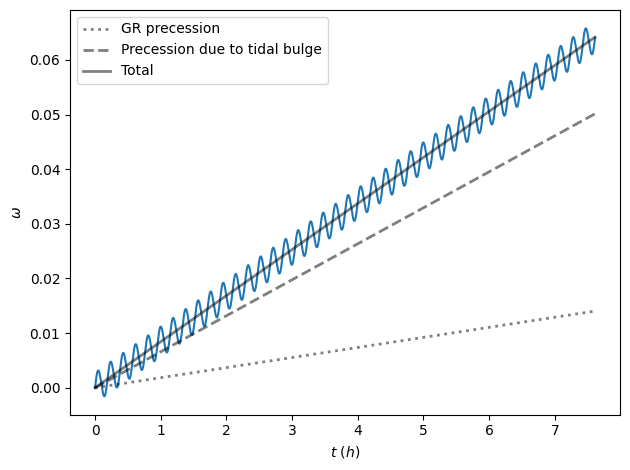

In [9]:
plt.plot(times, (omega + np.pi) % (2*np.pi) - np.pi)
plt.plot(times, omega_pred_GR, 'k:', lw=2, label='GR precession', alpha=0.5)
plt.plot(times, omega_pred_tide, 'k--', lw=2, label='Precession due to tidal bulge', alpha=0.5)
plt.plot(times, omega_pred_tide + omega_pred_GR, 'k', lw=2, label='Total', alpha=0.5)
plt.xlabel(r'$t\ (h)$')
plt.ylabel(r'$\omega$')
plt.legend()
plt.tight_layout()
plt.show()

The precession timescale for the inner binary is short compared to the periodicity of $\approx 171$ days that is observed. This shows that we can't just set up a triple system with a Kozai period of 171 days, because the rapid precession of the inner binary would cancel out the Kozai effect. In fact, as shown by Zdziarski et al. and Prodan & Murray, we need to look at the situation where the Kozai precession and inner binary precession almost cancel each other.

## The triple system: secular evolution equations

First, see if we can reproduce the results from Zdziarski et al. and Prodan and Murray using `kozai`. We added extra flags to the code so that we can turn on GR precession without also turning on GR radiation, and also added the precession due to the tidal bulge (see [this fork](https://github.com/andrewcumming/kozai) of the code).

Mean peak spacing = 171.03 d


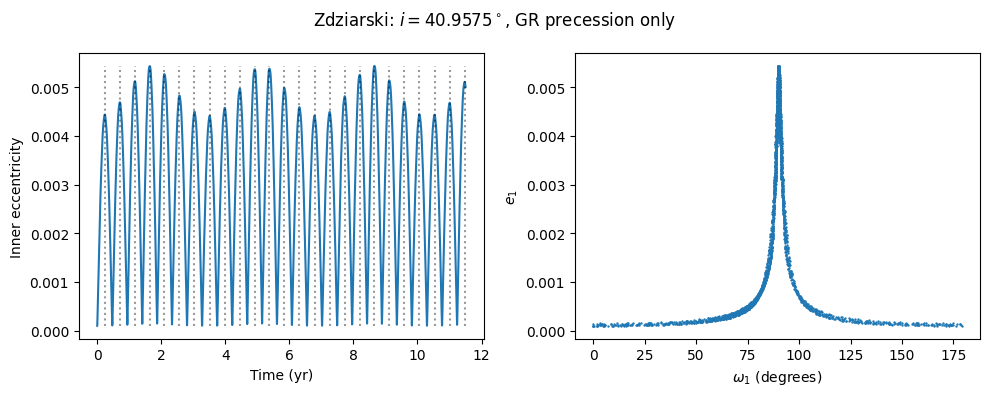

In [38]:
# Zdziarski -- GR precession only (no tidal bulge) -- reproduces their Figure 4 top panel
params_zdz = dict(
    name = 'zdz',
    m1 = 1.29, m2 = 0.07, m3 = 0.5,
    ecc1 = 1e-4, ecc2 = 1e-4,
    a_outer = 8.66,
    omega0 = 0,
    P1 = 685, # seconds
    R2 = 0,  # white dwarf radius needed for tidal bulge
    k2 = 0   # tidal Love number for the WD
)

def integrate_secular(inclination, params, tidal=False, octupole=True, tau_a=0, t_end = 11.5):
    # Integrate the secular equations using the kozai code
    a1 = (params['P1']/yr2s)**(2/3) * (params['m1']+params['m2'])**(1/3)   # we need a in AU, so rescale from the solar system
    Porb_inner = params['P1']/yr2s  # orbital period in years
    triple = TripleDelaunay(a1=a1, a2=params['a_outer']*a1, e1=params['ecc1'], e2=params['ecc2'], inc=inclination, 
                            m1=params['m1'], m2=params['m2'], m3=params['m3'], g1=params['omega0'] + 180)
    triple.octupole = octupole
    triple.hexadecapole = False
    triple.outfreq = 3
    triple.gr_precession = True  # include relativistic precession term
    triple.gr_radiation = False # but not the gravitational radiation terms
    triple.tidal_bulge = tidal
    triple.tau_a = tau_a
    if tidal:
        triple.k2 = params['k2']
        triple.r2 = params['R2'] / Rsun
    res = triple.evolve(t_end)

    return res

def plot_secular(res, plot_title, all_plots=False):
    # Plot the eccentricity evolution
    fig = plt.figure(figsize = (10,4))
    gs = fig.add_gridspec(1,2)
    
    fig.suptitle(plot_title)
    
    fig.add_subplot(gs[0, 0])
    plt.plot(res[:,0],res[:,2])
    plt.ylabel('Inner eccentricity')
    plt.xlabel('Time (yr)')

    emin = np.min(res[:,2])
    emax = np.max(res[:,2])
    ind, properties = find_peaks(res[:,2], distance = len(res[:,2]) * 0.1/(res[-1,0]-res[0,0]), height = emin + 0.5*(emax-emin))
    peak_times = res[ind,0]
    PK = np.mean(peak_times[1:-1]-peak_times[:-2])
    print("Mean peak spacing = %.2f d" % (PK*365.25,))
    for time in peak_times:
        plt.plot((time,time),(emin,emax),'k:',alpha=0.4)
    
    fig.add_subplot(gs[0, 1])
    plt.scatter(res[:,3] % 180, res[:,2], s=0.5)    
    plt.ylabel(r'$e_1$')
    plt.xlabel(r'$\omega_1$ (degrees)')
    plt.tight_layout()
    plt.show()

    if all_plots:
        fig = plt.figure(figsize = (10,3))
        gs = fig.add_gridspec(1,3)
                
        fig.add_subplot(gs[0, 0])
        plt.plot(res[ind[1:],0],365.25 * (peak_times[1:]-peak_times[:-1]),'o')
        plt.ylabel('Kozai period (d)')
        plt.xlabel('Time (yr)')
        #plt.plot(res[:,0],res[:,1])
        #plt.ylabel('Inner semi-major axis')
        #plt.xlabel('Time (yr)')
            
        fig.add_subplot(gs[0, 1])
        plt.scatter(res[:,0], res[:,7], s=0.5)    
        plt.ylabel(r'$i$')
        plt.xlabel('Time (yr)')

        fig.add_subplot(gs[0, 2])
        plt.scatter(res[:,0], res[:,3], s=0.5)    
        plt.ylabel(r'$\omega_p$')
        plt.xlabel('Time (yr)')

        plt.tight_layout()
        plt.show()


inclination = 40.9575   #40.96 # inclination in degrees
res = integrate_secular(inclination, params_zdz, octupole=True)
plot_secular(res, rf'Zdziarski: $i={inclination:g}^\circ$, GR precession only')

Mean peak spacing = 171.13 d


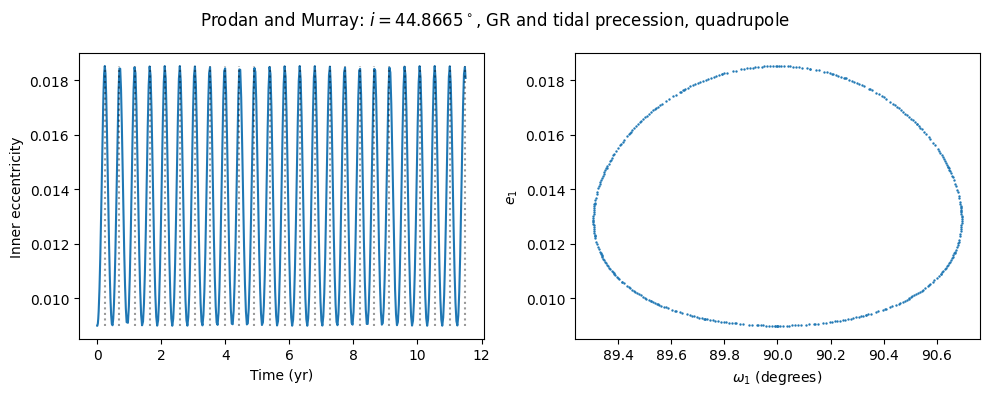

Mean peak spacing = 171.16 d


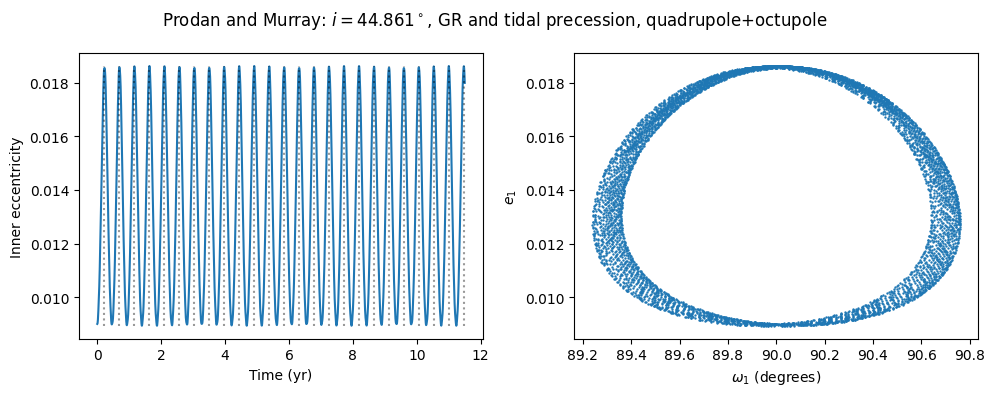

In [39]:
# Prodan and Murray -- GR and tidal precession
params_prodan = dict(
    name = 'prodan',
    m1 = 1.4, m2 = 0.067, m3 = 0.55,
    ecc1 = 0.009, ecc2 = 1e-4,
    a_outer = 8.0,
    omega0 = 90,
    P1 = 685, # seconds
    R2 = 2.2e9,  # white dwarf radius needed for tidal bulge
    k2 = 0.01   # tidal Love number for the WD
)

#inclination = 44.715
inclination = 44.8665
res = integrate_secular(inclination, params_prodan, tidal=True, octupole=False)
plot_secular(res, rf'Prodan and Murray: $i={inclination:g}^\circ$, GR and tidal precession, quadrupole')

inclination = 44.861
res = integrate_secular(inclination, params_prodan, tidal=True, octupole=True)
plot_secular(res, rf'Prodan and Murray: $i={inclination:g}^\circ$, GR and tidal precession, quadrupole+octupole')

These results look very similar to Prodan & Murray, we just had to choose a slightly different inclination. One difference is that Prodan & Murray work in the limit where the angular momentum of the outer binary is much larger than the inner binary, so that the outer binary is fixed in space, whereas the equations solved by `kozai` from Blaes et al. do not make this assumption. Taking this limit in the equations of Blaes et al. (in their notation taking $G_2\gg G_1$), the quadrupole term in their equation (12) does indeed reduce to the equation for $\dot{\omega}$ given by equation (A14) of Prodan & Murray.

In [40]:
# Check the size of G2/G1: we can use equations 6 and 7 of Blaes et al.
def angular_momentum_ratio(params):
    m1 = params['m1']
    m2 = params['m2']
    m3 = params['m3']
    a_outer = params_prodan['a_outer']
    return (m3/m1/m2)*(m1+m2)**(3/2)/(m1+m2+m3)**(1/2) * a_outer**(1/2)

angular_momentum_ratio(params_prodan)      

20.748995011218337

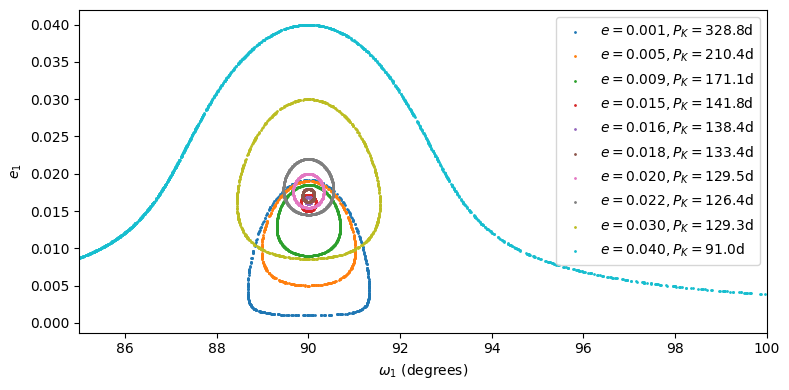

In [41]:
inclination = 44.8665 # 44.715

plt.figure(figsize=(8,4))

for ecc in (0.001, 0.005, 0.009, 0.015, 0.016, 0.018, 0.02, 0.022, 0.03, 0.04):
    params_prodan['ecc1'] = ecc
    res = integrate_secular(inclination, params_prodan, tidal=True, octupole=False)

    emin = np.min(res[:,2])
    emax = np.max(res[:,2])
    ind, properties = find_peaks(res[:,2], distance = len(res[:,2]) * 0.1/(res[-1,0]-res[0,0]), height = emin + 0.7*(emax-emin))
    peak_times = res[ind,0]
    PK = np.mean(peak_times[1:-1]-peak_times[:-2])
    #print("e = %.3f PK = %.2f d" % (ecc, PK*365.25))

    plt.scatter(res[:,3] % 180, res[:,2], s=1, label=r'$e=%.3f, P_K=%.1f$d' % (ecc,PK*365.25,))    


plt.ylabel(r'$e_1$')
plt.legend()
plt.xlabel(r'$\omega_1$ (degrees)')
plt.xlim((85,100))
plt.tight_layout()
plt.show()
        
params_prodan['ecc1'] = 0.009

## The triple system with REBOUND

Now we're ready to integrate the triple system. Since the oscillation period is very sensitive to inclination (e.g. Prodan & Murray 2012 Figure 1), we'll set this up so that we can easily run the evolution for different choices of inclination.

In [51]:
def run_triple(inclination, params, include_tidal_bulge=False, tau_a=1e20, Norbits=5e4, all_plots=False):

    # REBOUND integration of the orbits
    sim = rebound.Simulation()
    
    # calculate c in these units for the GR term
    m12 = params['m1'] + params['m2']
    a_cm = (params['P1']/2/np.pi)**(2/3) * (Ggrav*Msun*m12)**(1/3)
    v_unit = (Ggrav*Msun*m12**(1/3)/a_cm)**(1/2)
    c_code = clight/v_unit
   
    rebx = reboundx.Extras(sim)
    gr = rebx.load_force("gr_full")
    rebx.add_force(gr)
    gr.params["c"] = c_code
    
    sim.add(m = params['m1'])
    sim.add(m = params['m2'], a = 1, e = params['ecc1'], omega = np.deg2rad(params['omega0']), Omega=0)
    sim.add(m = params['m3'], a = params['a_outer'], e = params['ecc2'], inc=np.deg2rad(inclination), omega=0)
    sim.move_to_com()

    mof = rebx.load_force("modify_orbits_forces")
    rebx.add_force(mof)
    Porb1 = sim.orbits()[0].P
    ps = sim.particles
    ps[1].params['tau_a'] = (tau_a * yr2s / params['P1']) * Porb1

    if include_tidal_bulge:
        tides = rebx.load_force('tides_constant_time_lag')
        rebx.add_force(tides)
        ps[1].r = params['R2'] / a_cm # WD radius
        ps[1].params['tctl_k2'] = params['k2']  # WD Love number

    # rotate to the invariable plane so that we can compare with the secular calculation
    rot = rebound.Rotation.to_new_axes(newz=sim.angular_momentum())
    sim.rotate(rot)
    
    Noutputs = 10000
    times = np.linspace(0, Norbits*Porb1, Noutputs)
    # initialize empty arrays for output
    a1, a2, e1, e2, i1, i2, omega1, Omega1, Omega2 = [np.zeros(Noutputs) for _ in range(9)]
    
    for i, t in enumerate(times):
        sim.integrate(t, exact_finish_time=1)
        o1 = sim.orbits()[0]
        o2 = sim.orbits()[1]    
        a1[i], a2[i] = o1.a, o2.a
        e1[i], e2[i] = o1.e, o2.e
        i1[i], i2[i] = o1.inc, o2.inc
        Omega1[i], Omega2[i] = o1.Omega, o2.Omega
        omega1[i] = o1.omega
    
    # calculate the mutual inclination
    cos_imut = (np.cos(i1)*np.cos(i2) + np.sin(i1)*np.sin(i2)*np.cos(Omega1 - Omega2))
    imut = np.arccos(cos_imut)
    
    times = (times/Porb1) * (params['P1']/yr2s)

    fig = plt.figure(figsize = (10,4))
    gs = fig.add_gridspec(1,2)

    fig.add_subplot(gs[0, 0])
    plt.plot(times, e1)
    plt.ylabel('Inner eccentricity')
    plt.xlabel('Time (yr)')

    emin = np.min(e1)
    emax = np.max(e1)
    ind, properties = find_peaks(e1, distance = len(e1) * 0.1/(times[-1]-times[0]), height = emin + 0.5*(emax-emin))
    peak_times = times[ind]
    PK = np.mean(peak_times[1:]-peak_times[:-1])
    #print("Mean peak spacing = %.2f d" % (PK*365.25,))
    for time in peak_times:
        plt.plot((time,time),(emin,emax),'k:',alpha=0.4)

    fig.suptitle(rf'$i={inclination:g}^\circ$, period$={PK*365.25:g}, e_0={params['ecc1']:g}$')
    
    fig.add_subplot(gs[0, 1])
    plt.scatter(np.rad2deg(omega1) % 180, e1, s=0.5)
    plt.ylabel(r'$e_1$')
    plt.xlabel(r'$\omega_1$ (degrees)')
    plt.tight_layout()

    name = params['name']
    ecc1 = params['ecc1']
    fname = f"plot_{name}_{ecc1}_{inclination}.png"
    #print('filename=',fname)
    fig.savefig(fname)

    if all_plots:
        plt.show()
        
        fig = plt.figure(figsize = (10,3))
        gs = fig.add_gridspec(1,3)
                
        fig.add_subplot(gs[0, 0])
        plt.plot(times[ind[1:]],365.25*(peak_times[1:]-peak_times[:-1]),'o')
        plt.ylabel('Kozai period (d)')
        plt.xlabel('Time (yr)')
            
        fig.add_subplot(gs[0, 1])
        plt.scatter(times, np.rad2deg(imut), s=0.5)    
        plt.ylabel(r'$i$')
        plt.xlabel('Time (yr)')

        fig.add_subplot(gs[0, 2])
        plt.scatter(times, np.rad2deg(omega1) , s=0.5)    
        plt.ylabel(r'$\omega_p$')
        plt.xlabel('Time (yr)')

        plt.tight_layout()
        plt.show()


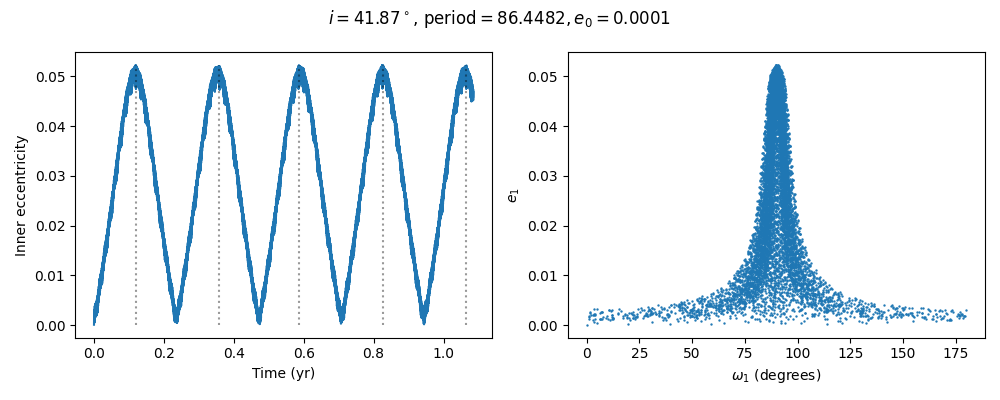

In [49]:
from IPython.display import Image, display
from concurrent.futures import ProcessPoolExecutor

# Zdziarski had i=40.96
incs = (41.87,)
ecc1 = params_zdz['ecc1']

def run_zdz(inc):
    run_triple(inc, params_zdz, include_tidal_bulge=False)

with ProcessPoolExecutor() as exe:
    results = list(exe.map(run_zdz, incs))

for inc in incs:
    display(Image(filename=f"plot_zdz_{ecc1}_{inc}.png"))

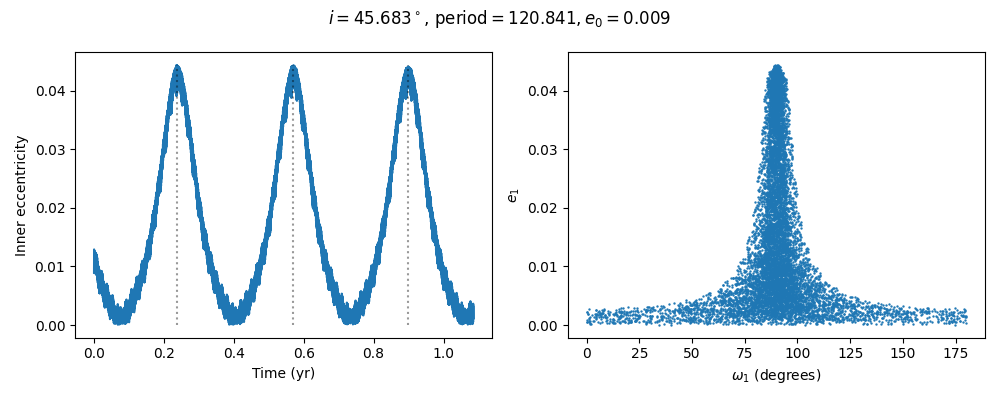

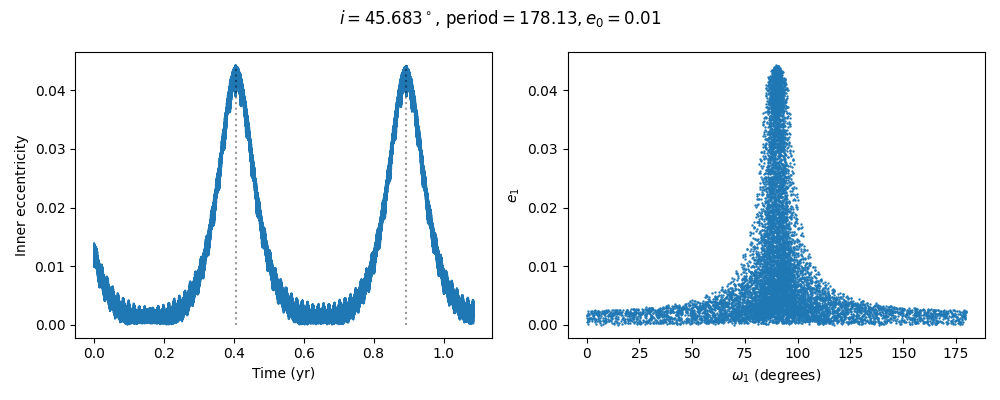

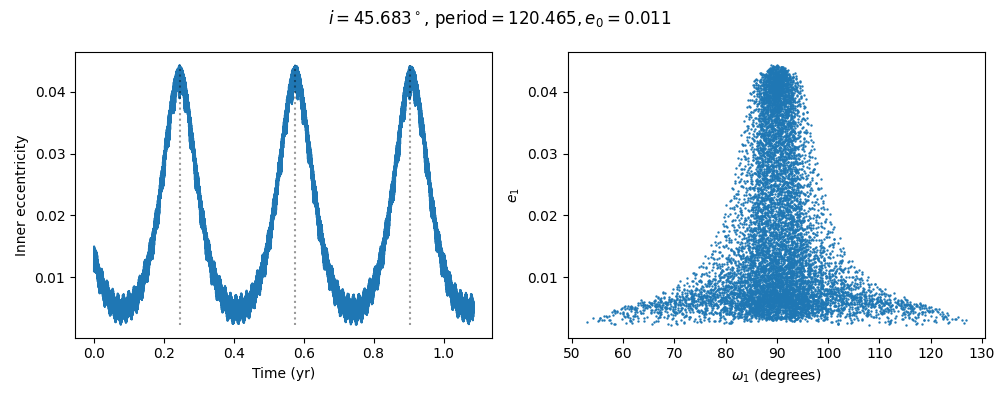

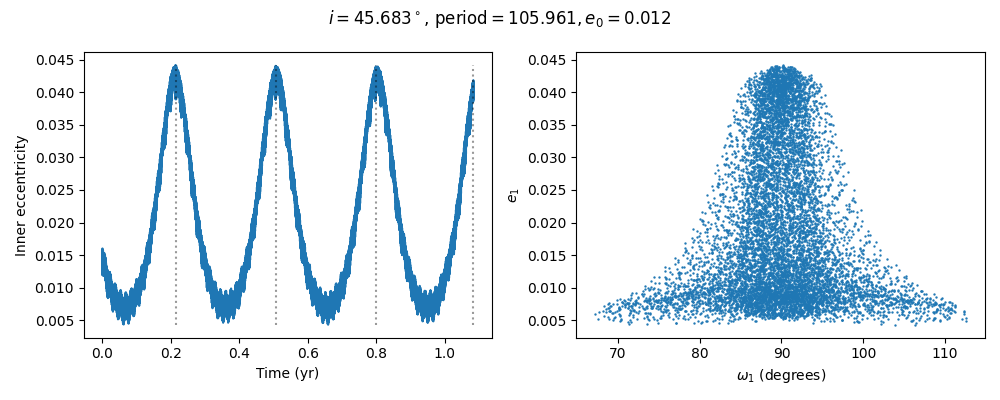

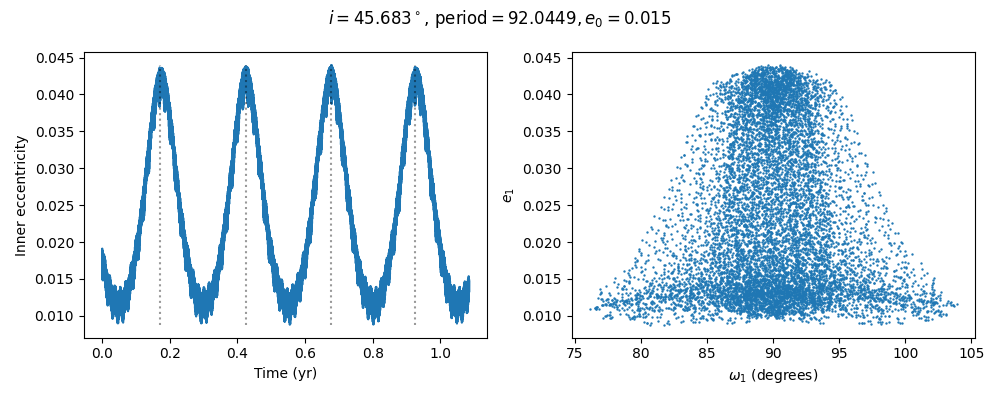

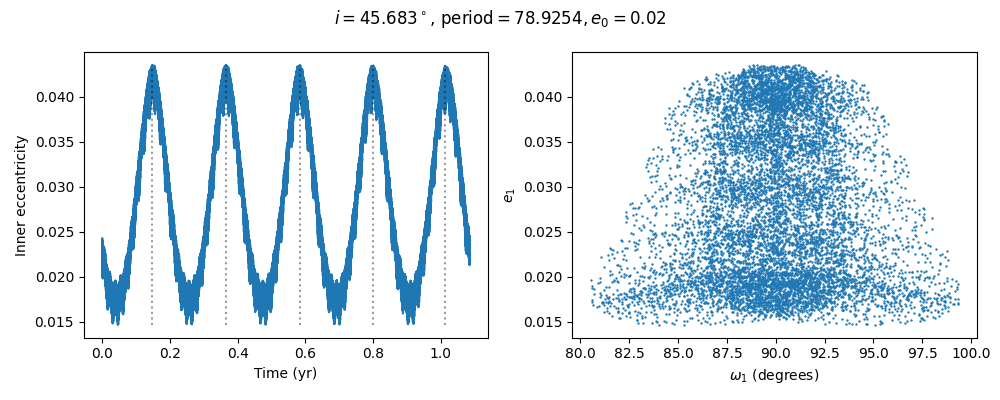

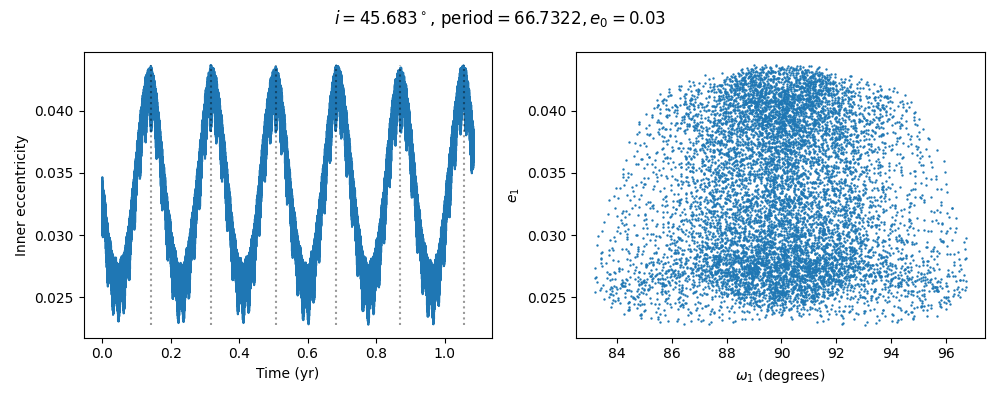

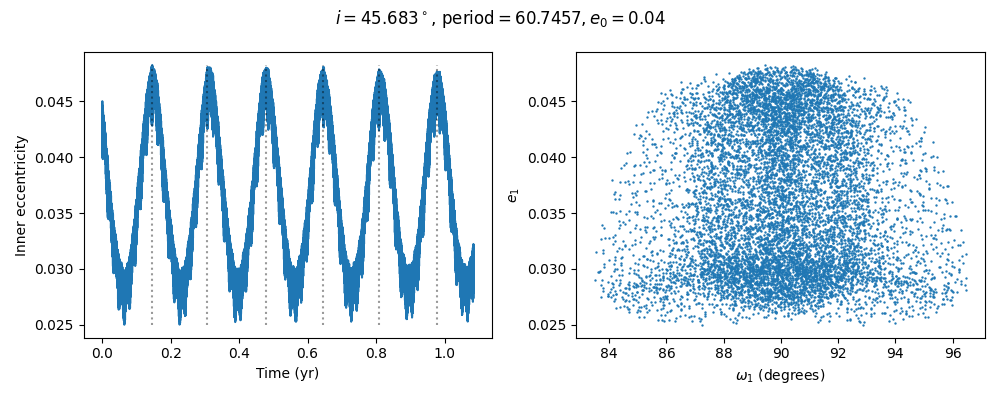

In [16]:
from IPython.display import Image, display
from concurrent.futures import ProcessPoolExecutor

eccs = (0.009, 0.01, 0.011, 0.012, 0.015, 0.02, 0.03, 0.04)
incs = (45.683,)

param_list = []
for inc in incs:
    for ecc in eccs:
        param_list.append((inc, ecc))
        
def run_prodan(p):
    params_prodan['ecc1'] = p[1]
    run_triple(p[0], params_prodan, include_tidal_bulge=True)

with ProcessPoolExecutor() as exe:
    results = list(exe.map(run_prodan, param_list))

for p in param_list:
    display(Image(filename=f"plot_prodan_{p[1]}_{p[0]}.png"))

## Expansion of the inner binary and capture into resonance

Next add an increasing semi-major axis for the inner orbit, $da_1/dt = a_1/\tau_a$, where $\tau_a$ is a parameter that we can set (in fact it will be determined by the mass transfer between the two stars in the inner binary). Here we choose a much faster timescale $\tau_a\approx 10^4$ years than in the actual system (where the evolution time is $\sim 10^{9}$ years or longer).

Mean peak spacing = 83.52 d


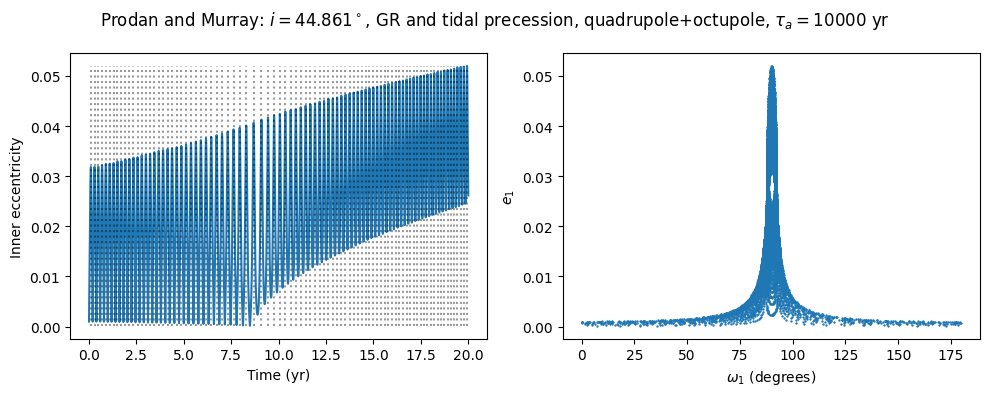

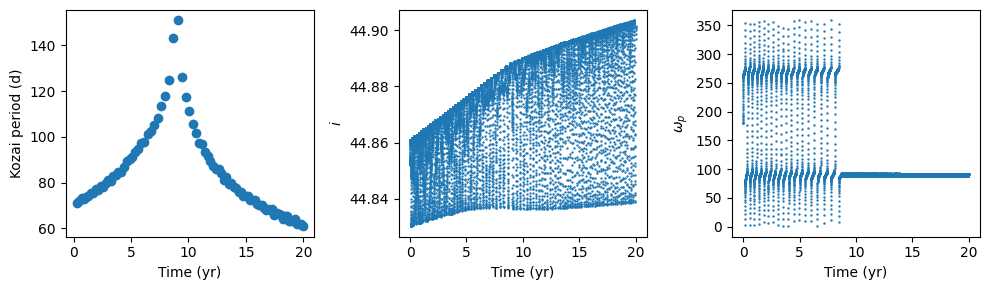

In [54]:
# Prodan and Murray -- GR and tidal precession
params_prodan = dict(
    name = 'prodan',
    m1 = 1.4, m2 = 0.067, m3 = 0.55,
    ecc1 = 1e-3, ecc2 = 1e-4,
    a_outer = 8.0,
    omega0 = 0,
    P1 = 685, # seconds
    R2 = 2.2e9,  # white dwarf radius needed for tidal bulge
    k2 = 0.01   # tidal Love number for the WD
)

inclination = 44.861
tau_a = 1e4
res = integrate_secular(inclination, params_prodan, tidal=True, octupole=True, tau_a=tau_a, t_end = 20)
plot_secular(res, rf'Prodan and Murray: $i={inclination:g}^\circ$, GR and tidal precession, quadrupole+octupole, $\tau_a={tau_a:g}$ yr', 
             all_plots=True)

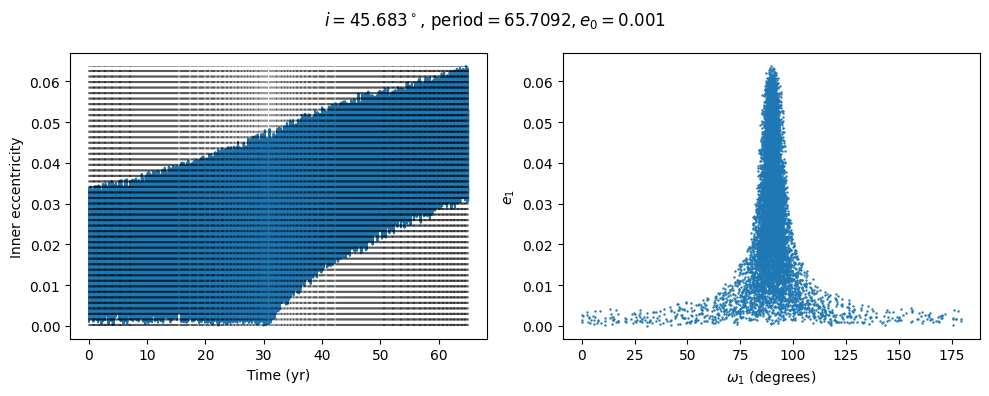

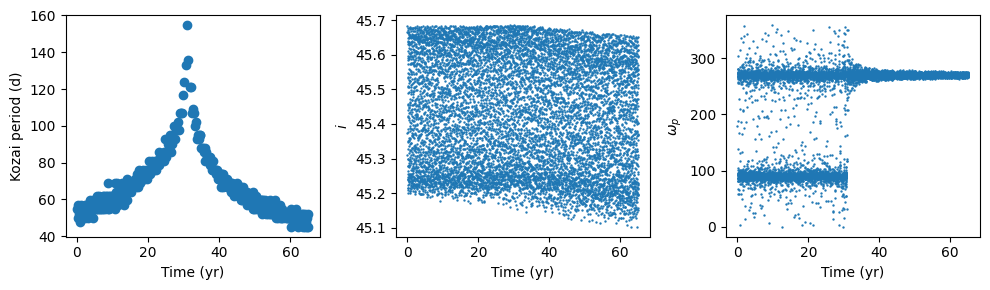

In [55]:
# Prodan and Murray -- GR and tidal precession
params_prodan = dict(
    name = 'prodan',
    m1 = 1.4, m2 = 0.067, m3 = 0.55,
    ecc1 = 0.001, ecc2 = 1e-4,
    a_outer = 8.0,
    omega0 = 0,
    P1 = 685, # seconds
    R2 = 2.2e9,  # white dwarf radius needed for tidal bulge
    k2 = 0.01   # tidal Love number for the WD
)

run_triple(45.683, params_prodan, Norbits=3e6, include_tidal_bulge=True, tau_a=1e4, all_plots=True)

Both the REBOUND and secular calculations show simular behaviour. In both cases, we see that the system is captured into the Kozai resonance with $\omega_p\approx 90$ or $270$ degrees. The Kozai period is only near the observed value (171 days) for a short time: as the system moves closer to the fixed point, the timescale drops.